In [ ]:
import numpy as np
import jax
import jax.numpy as jnp
import jax.random as jr
import equinox as eqx
import optax
from dyn_modelling.models.cell_lattice import build_lattice, compute_distance_matrix, simulate_cell_lattice, compute_rhs
from dyn_modelling.methods.deepOnet import DeepONet, train_validation
from dyn_modelling.utils.data import generate_deeponet_dataset
from dyn_modelling.utils.plots import plot_graph, plot_trajectories, plot_train_val_loss, plot_predictions , plot_predictions_grid_test

Operator: $S_ext(·) → x(i, var, t)$

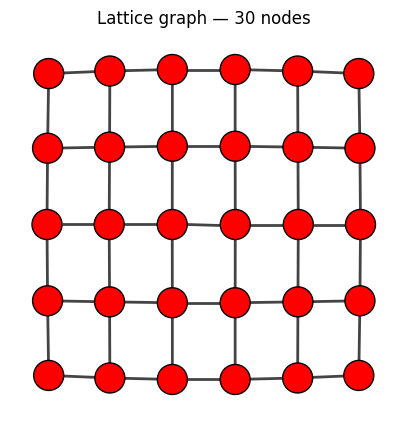

In [2]:
# cell 3 [code]
rows, cols = 5, 6
N = rows * cols

g = build_lattice(rows, cols)
plot_graph(g)

In [3]:
a_params    = np.array([2.4, 3.5, 2.0, 1.0])
l_params    = np.array([1.0, 1.0, 0.2])
neigh_order = 2
t_end       = 100.0
n_steps     = 50
t_eval      = np.linspace(0, t_end, n_steps)

np.random.seed(1)
x0 = np.random.rand(N * 3)

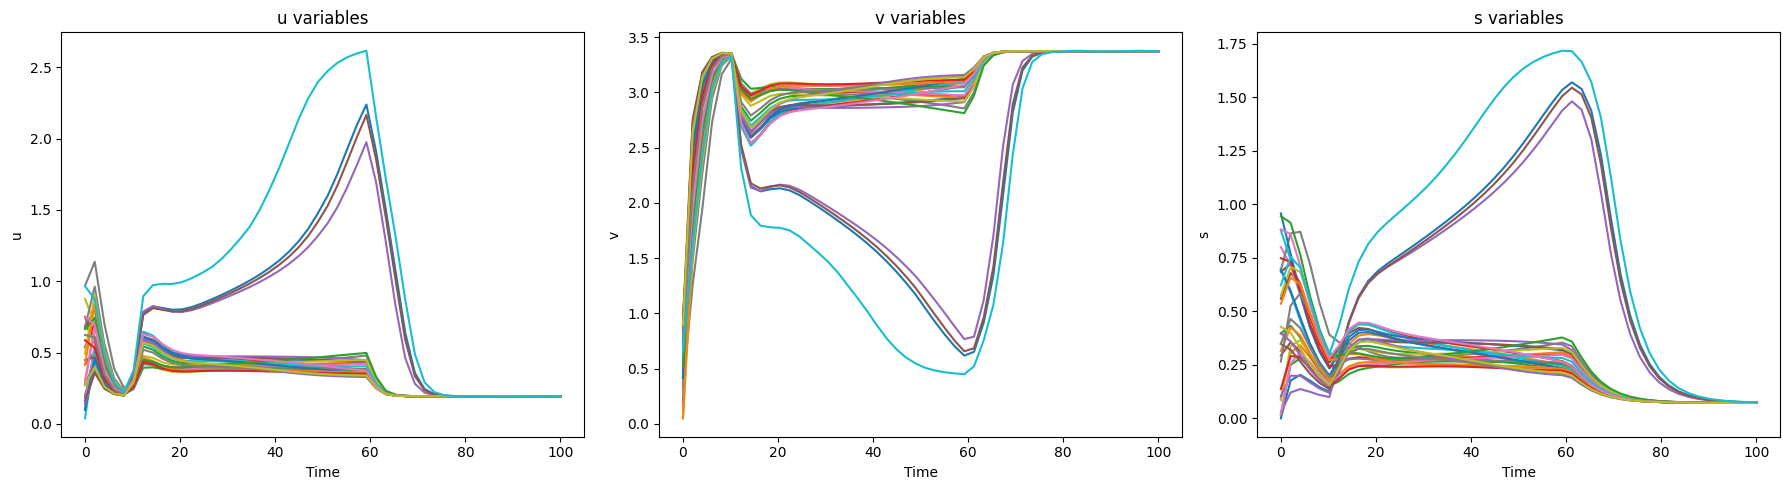

In [4]:
dist_matrix = compute_distance_matrix(g)
rhs_ref = compute_rhs(g, dist_matrix, l_params, neigh_order,
                      t_on=10.0, t_off=60.0, a_params=a_params)
y_ref = simulate_cell_lattice(rhs_ref, x0, (0, t_end), t_eval)

plot_trajectories(t_eval, y_ref)

In [30]:
#generate deeponet dataset
#deepOnet needs to be trained on multiple trajectories

data = generate_deeponet_dataset(
    n_traj      = 300,
    rows        = rows,
    cols        = cols,
    l_params    = l_params,
    a_params    = a_params,
    neigh_order = neigh_order,
    x0          = x0,
    t_span      = (0.0, t_end),
    t_eval      = t_eval,
    seed        = 42,
    rescale     = True
)

print("signal :", data["signal"].shape)   
print("queries      :", data["queries"].shape)         
print("outputs      :", data["outputs"].shape)        

signal : (300, 50)
queries      : (4500, 3)
outputs      : (300, 4500)


In [31]:
#train/validation/test split

n_train = 240
n_val   = 30
n_test  = 30

signal_train = data["signal"][:n_train]
y_train      = data["outputs"][:n_train]

signal_val   = data["signal"][n_train:n_train + n_val]
y_val        = data["outputs"][n_train:n_train + n_val]

signal_test  = data["signal"][n_train + n_val:]
y_test       = data["outputs"][n_train + n_val:]

queries      = data["queries"]       

In [32]:
input_size = n_steps   # branch input size = number of sensor times

model = DeepONet( 
    input_size_branch = input_size,
    input_size_trunk = 3,
    width_size = 256,
    depth        = 4,
    interact_size= 256,
    key          = jr.PRNGKey(0),
)

In [33]:
schedule = optax.exponential_decay(
    init_value=1e-3,
    transition_steps=1000,
    decay_rate=0.9,
)
optimizer = optax.adam(schedule)
#model, loss_history = train(model, optimizer, signal_train, queries, y_train, n_epochs=10000)

In [34]:
model, train_loss_history, val_loss_history, val_steps = train_validation(
    model, optimizer,
    signal_train, queries, y_train,
    signal_val, y_val,          
    n_epochs=20000,
    val_every=100,
)

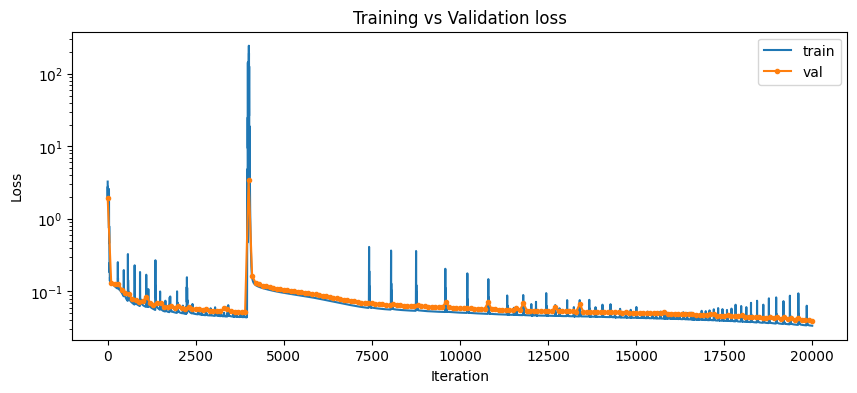

In [35]:
plot_train_val_loss(train_loss_history, val_loss_history, val_steps)

In [36]:
predictions_test = jax.vmap(
    jax.vmap(model, in_axes=(None, 0)),
    in_axes=(0, None)
)(signal_test, queries)   

errors = jax.vmap(
    lambda p, r: jnp.linalg.norm(p - r) / jnp.linalg.norm(r)
)(predictions_test, y_test)

print(f"mean rel. L2 error : {jnp.mean(errors):.4f}")
print(f"std  rel. L2 error : {jnp.std(errors):.4f}")

mean rel. L2 error : 0.0924
std  rel. L2 error : 0.0382


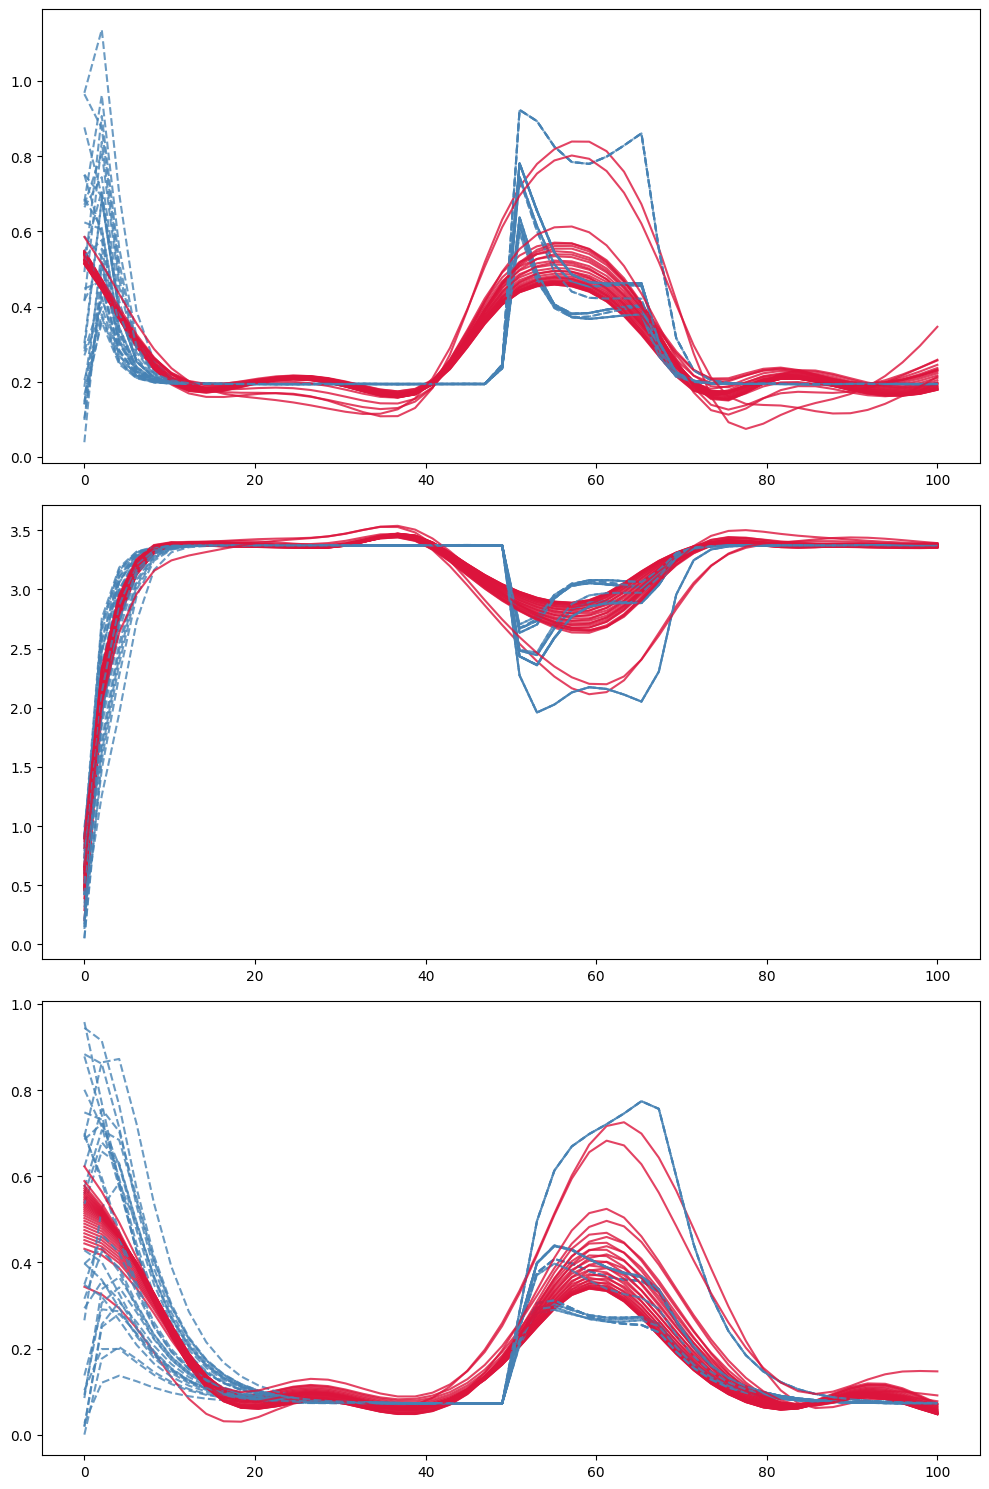

In [16]:
idx = 1
pred = np.array(predictions_test[idx])  # (n_queries,)
true = np.array(y_test[idx])            # (n_queries,)

# (n_cells * 3 * n_steps,) → (n_cells, 3, n_steps) → (n_steps, n_cells, 3)
pred_traj = pred.reshape(N, 3, n_steps).transpose(2, 0, 1).reshape(n_steps, 3 * N)
true_traj = true.reshape(N, 3, n_steps).transpose(2, 0, 1).reshape(n_steps, 3 * N)

plot_predictions(t_eval, pred_traj, true_traj)

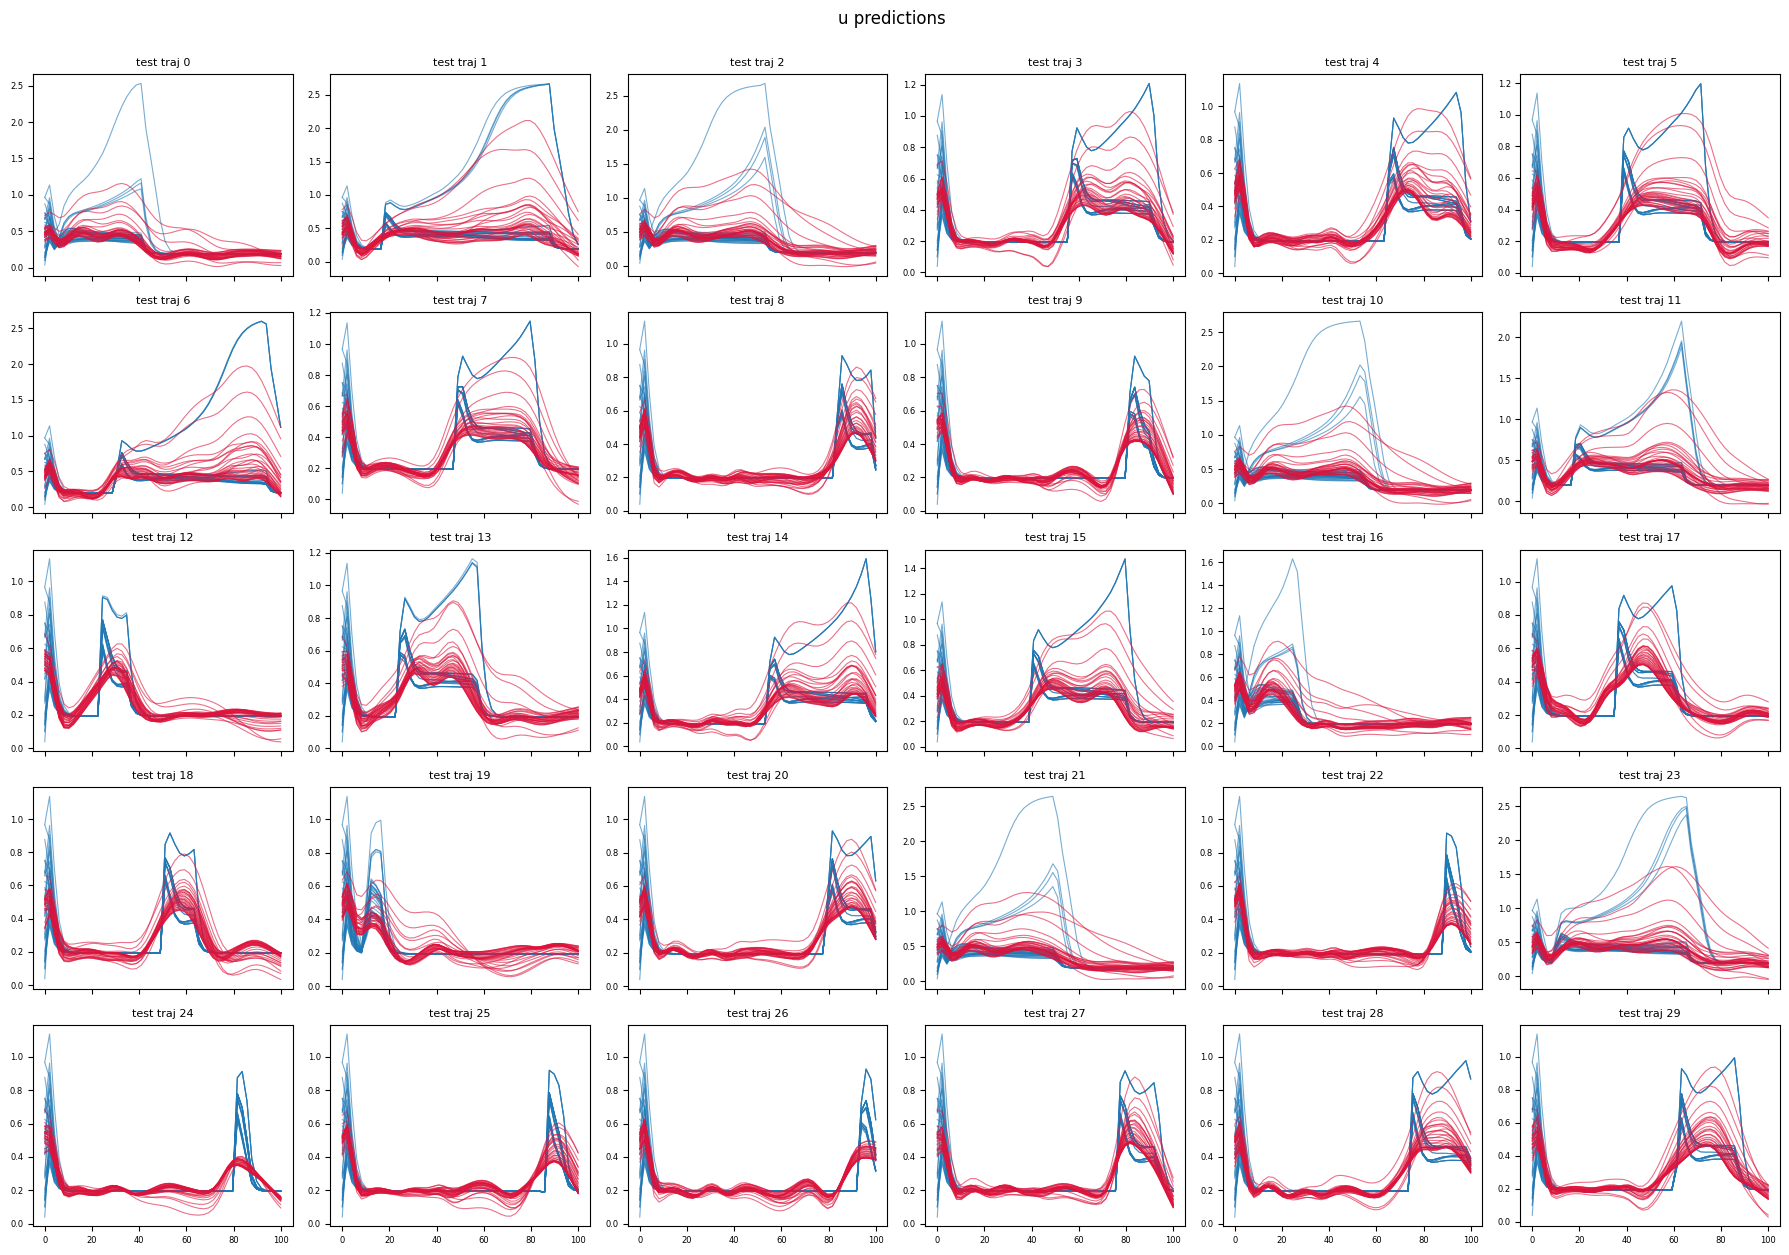

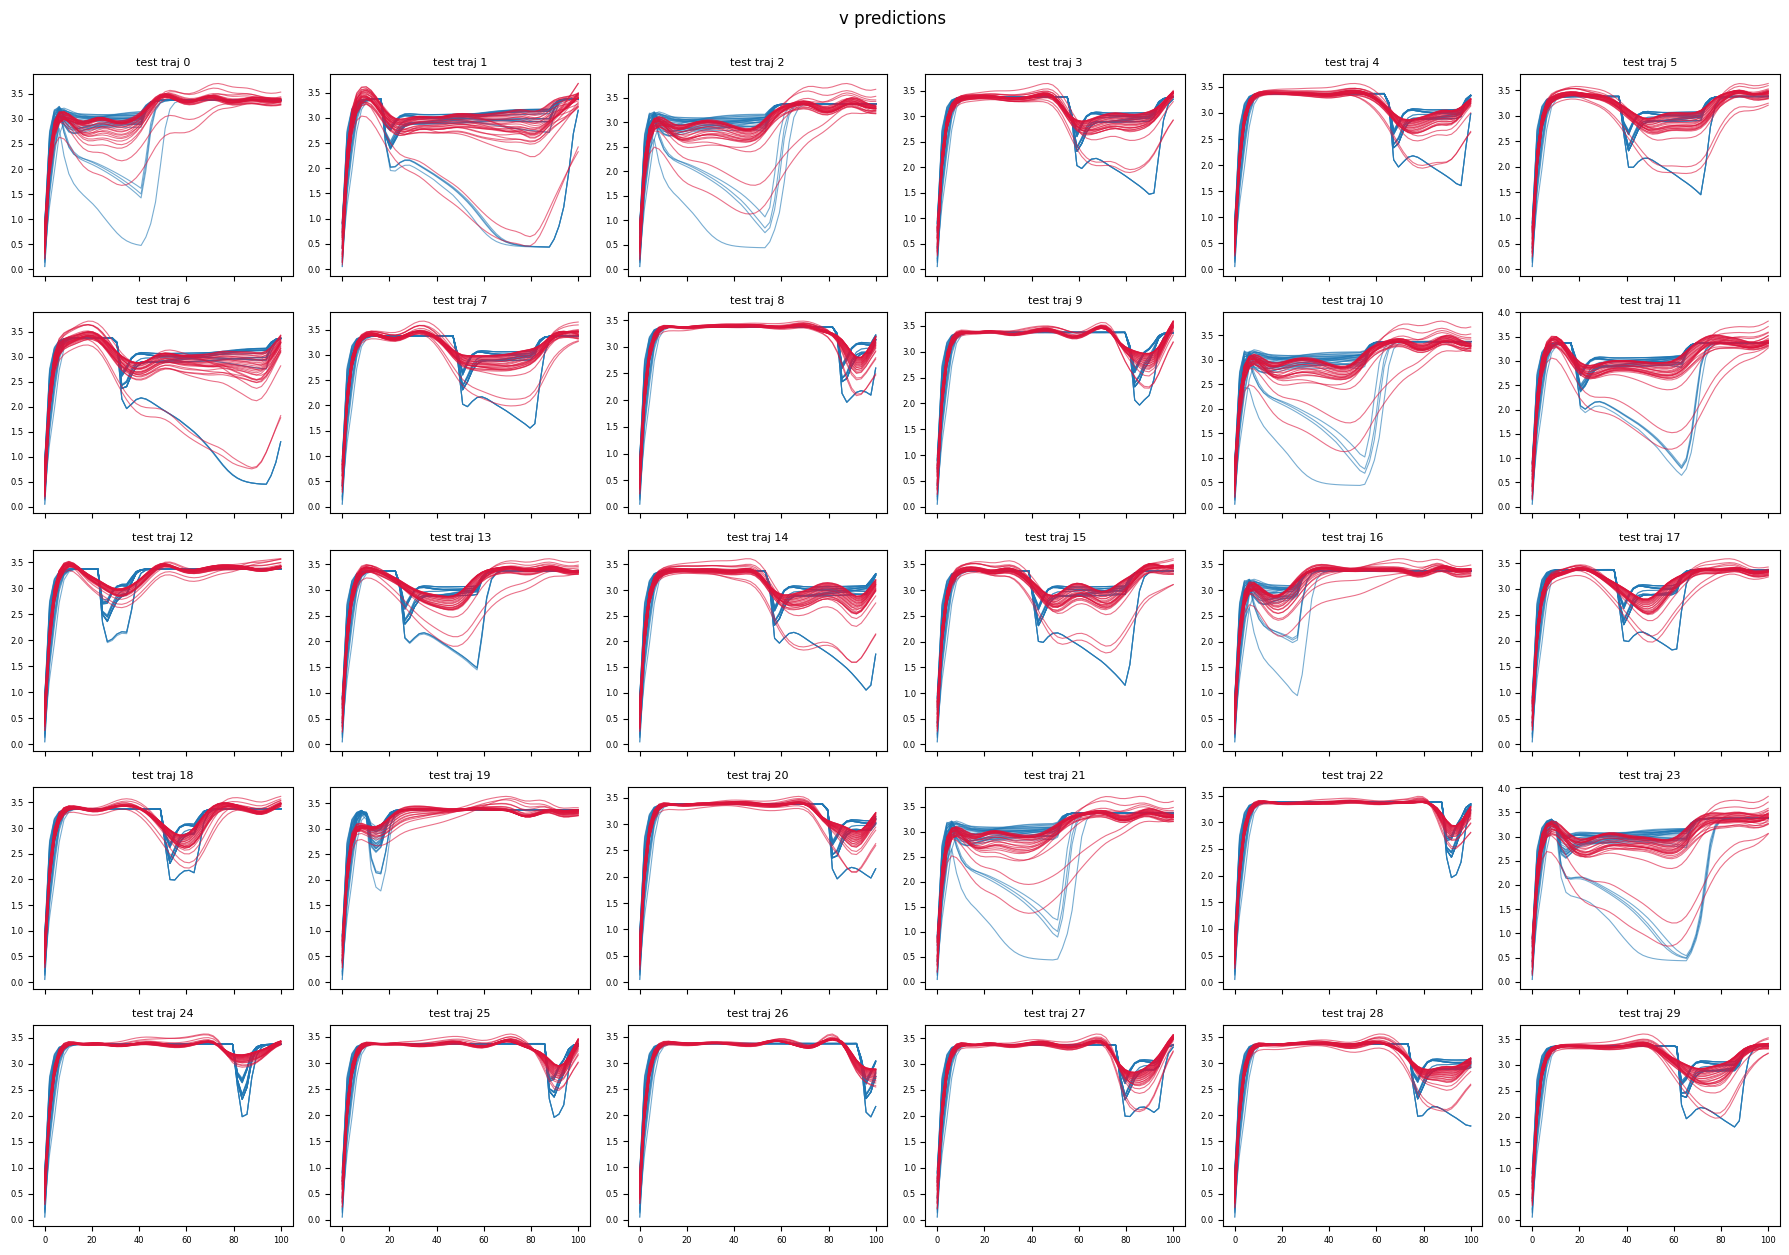

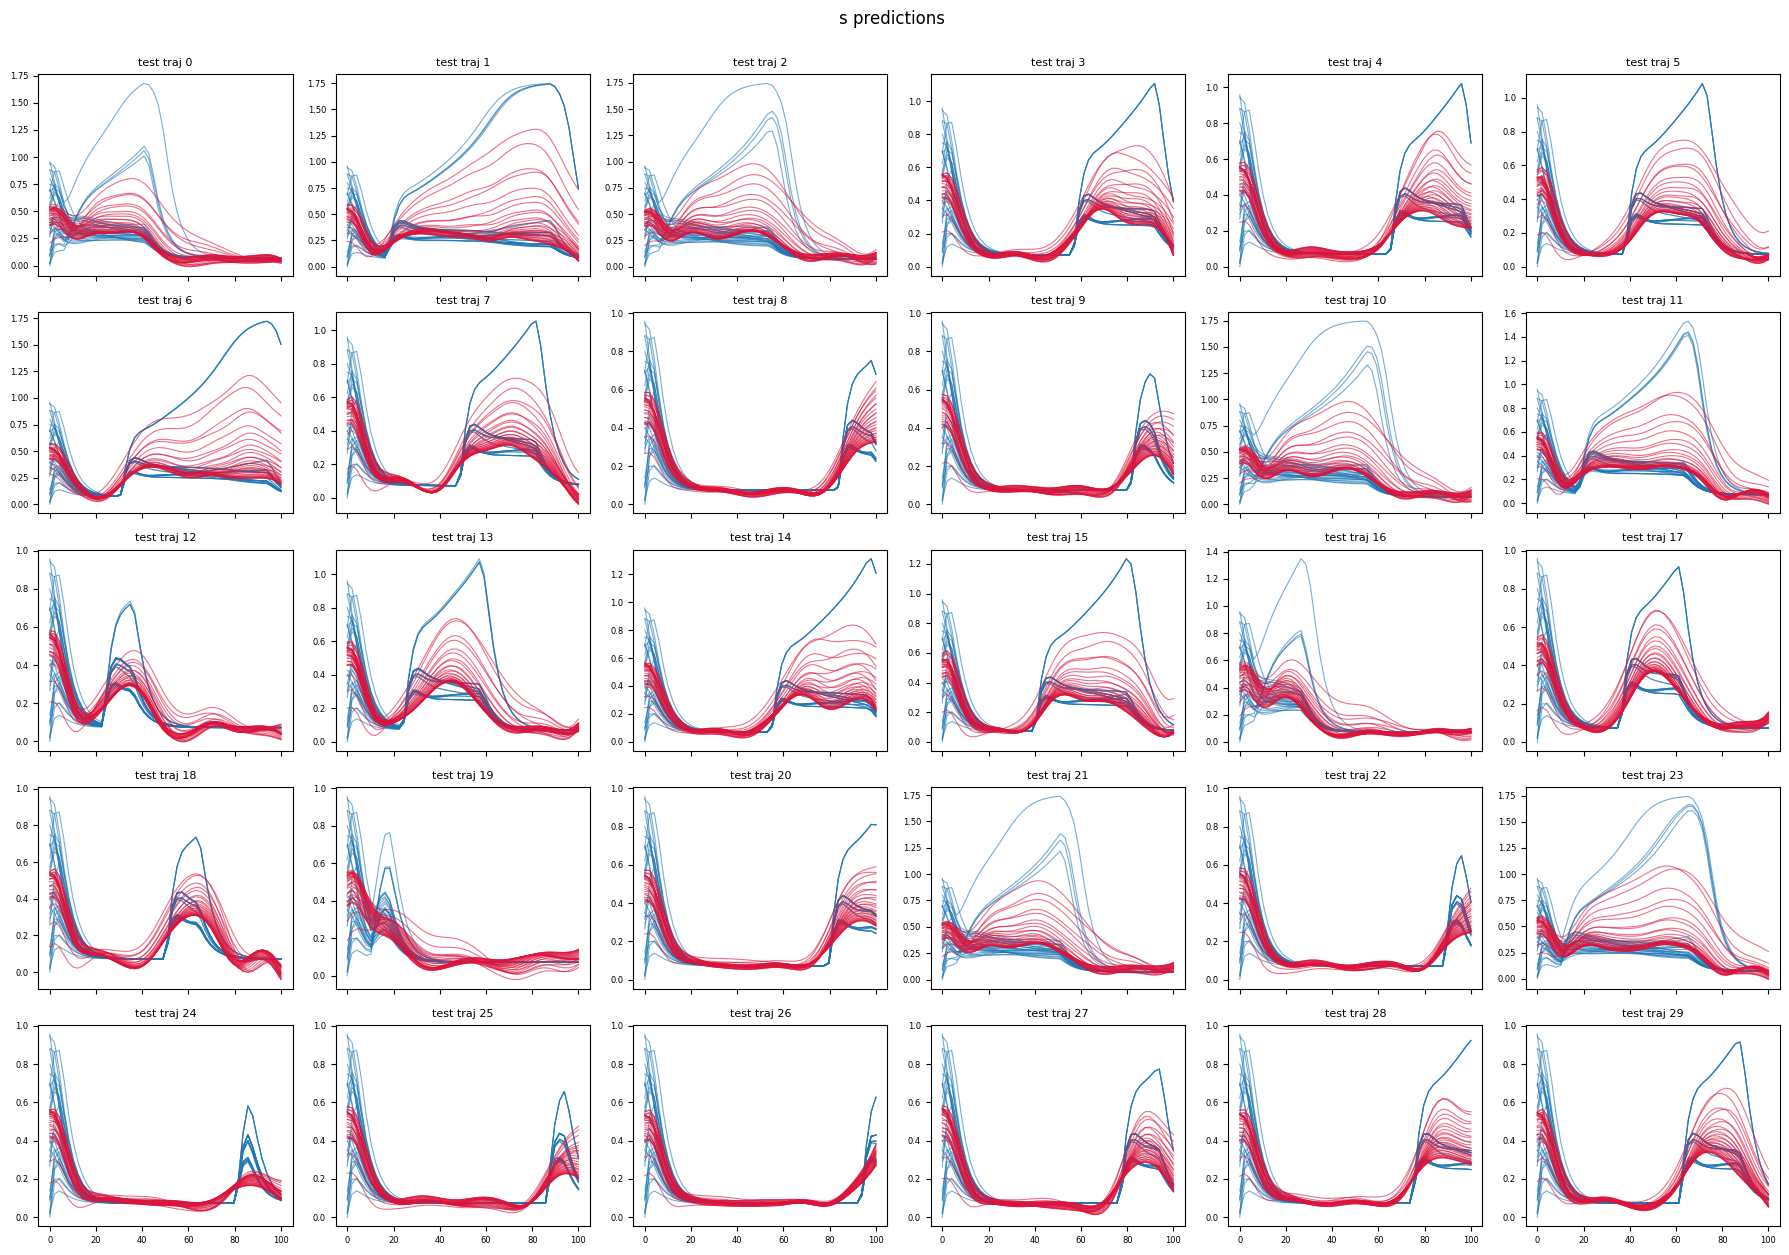

In [ ]:
for var_idx in range(3):
    fig = plot_predictions_grid_test(t_eval, predictions_test, y_test, N, n_steps, var_idx=var_idx)
    fig.show()